In [31]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path.cwd().parent.parent.parent
DATA_RAW = BASE_DIR / "data" / "raw"
DATA_PROCESSED = BASE_DIR / "data" / "processed"

df = pd.read_csv(DATA_PROCESSED / "ml_dataset.csv", sep=";")
df.head()

,is_rockstar,market_return,AR_event,franchise_gta,impact_label,impact_label_num,publisher_activision blizzard,publisher_ea,publisher_electronic arts,publisher_nintendo,...,event_type_corporate event,event_type_delay,event_type_earnings,event_type_leak,event_type_major announcement,event_type_release,event_type_trailer/reveal,sentiment_negative,sentiment_neutral,sentiment_positive
0,0,-0.012258,-0.001198,0,low,0,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
1,0,0.004073,-0.000318,0,low,0,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
2,0,0.010054,0.003422,0,low,0,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,0,0.049396,-0.016937,0,low,0,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
4,0,0.015163,-0.014124,0,medium,1,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [33]:
target = "impact_label_num"

X = df.drop(columns=["impact_label", "impact_label_num"])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (72, 20)
y shape: (72,)


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (54, 20)
Test size: (18, 20)


In [35]:
def evaluate_model(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"=== {name} ===")
    print("Accuracy:", round(acc, 3))
    print("F1-score (macro):", round(f1, 3))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Low","Med","High"],
                yticklabels=["Low","Med","High"])
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

=== Logistic Regression ===
Accuracy: 0.333
F1-score (macro): 0.297

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.43      0.46         7
           1       0.00      0.00      0.00         4
           2       0.43      0.43      0.43         7

    accuracy                           0.33        18
   macro avg       0.31      0.29      0.30        18
weighted avg       0.36      0.33      0.35        18



/files/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


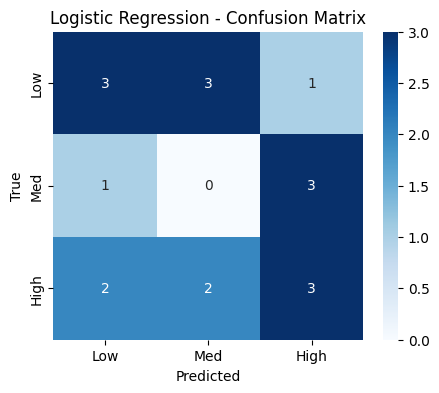

In [36]:
log_reg = LogisticRegression(max_iter=5000, multi_class="multinomial")
log_reg.fit(X_train, y_train)

evaluate_model(log_reg, X_test, y_test, name="Logistic Regression")

=== Random Forest ===
Accuracy: 0.278
F1-score (macro): 0.229

Classification Report:
               precision    recall  f1-score   support

           0       0.38      0.43      0.40         7
           1       0.00      0.00      0.00         4
           2       0.29      0.29      0.29         7

    accuracy                           0.28        18
   macro avg       0.22      0.24      0.23        18
weighted avg       0.26      0.28      0.27        18



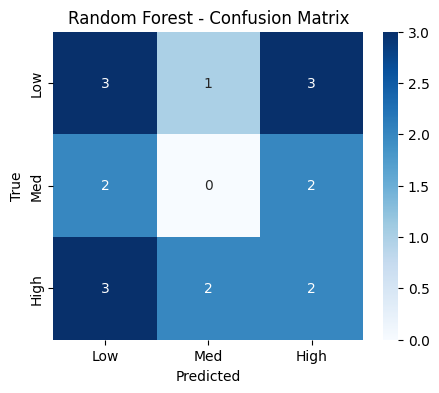

In [37]:
rf = RandomForestClassifier(n_estimators=300, max_depth=None, random_state=42)
rf.fit(X_train, y_train)
evaluate_model(rf, X_test, y_test, name="Random Forest")

=== Gradient Boosting ===
Accuracy: 0.444
F1-score (macro): 0.443

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.43      0.50         7
           1       0.33      0.50      0.40         4
           2       0.43      0.43      0.43         7

    accuracy                           0.44        18
   macro avg       0.45      0.45      0.44        18
weighted avg       0.47      0.44      0.45        18



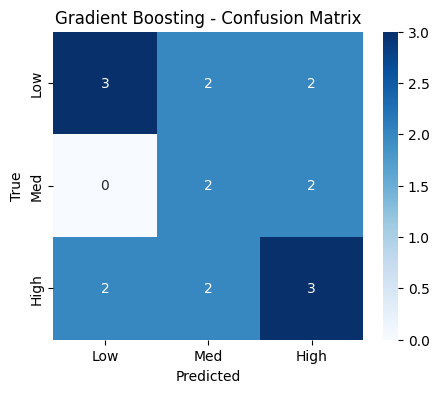

In [38]:
gb = GradientBoostingClassifier(learning_rate=0.05, n_estimators=300, random_state=42)
gb.fit(X_train, y_train)
evaluate_model(gb, X_test, y_test, name="Gradient Boosting")

=== Neural Network (MLP) ===
Accuracy: 0.222
F1-score (macro): 0.198

Classification Report:
               precision    recall  f1-score   support

           0       0.20      0.14      0.17         7
           1       0.00      0.00      0.00         4
           2       0.43      0.43      0.43         7

    accuracy                           0.22        18
   macro avg       0.21      0.19      0.20        18
weighted avg       0.24      0.22      0.23        18



/files/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


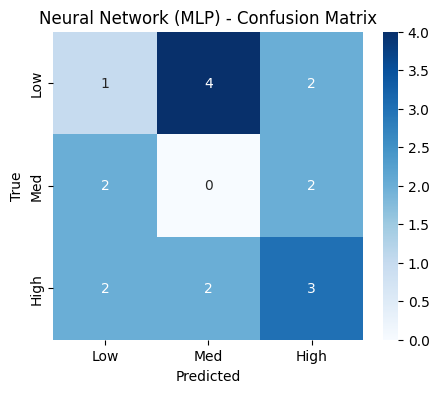

In [39]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp.fit(X_train, y_train)

evaluate_model(mlp, X_test, y_test, name="Neural Network (MLP)")

In [40]:
models = {"Logistic Regression": log_reg,
            "Random Forest": rf,
            "Gradient Boosting": gb,
            "Neural Network (MLP)": mlp}

results = []

for name, models in models.items():
    y_pred = models.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    results.append({"Model": name, "Accuracy": acc, "F1-score (macro)": f1})

pd.DataFrame(results, columns=["Model", "Accuracy", "F1-score (macro)"])

,Model,Accuracy,F1-score (macro)
0,Logistic Regression,0.333333,0.296703
1,Random Forest,0.277778,0.228571
2,Gradient Boosting,0.444444,0.442857
3,Neural Network (MLP),0.222222,0.198413


In [41]:
# ✅ Check train vs test accuracy
from sklearn.metrics import accuracy_score

y_train_pred = gb.predict(X_train)
y_test_pred = gb.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy:  {test_acc:.3f}")
print(f"Overfitting risk: {train_acc - test_acc:.3f}")

if train_acc - test_acc > 0.10:
    print("⚠️ WARNING: Possible overfitting")
else:
    print("✅ Good generalization")

Train Accuracy: 1.000
Test Accuracy:  0.444
Overfitting risk: 0.556
⚠️ WARNING: Possible overfitting


In [42]:
# --- Feature Importances from Gradient Boosting ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Extract importances
importances = gb.feature_importances_
feature_names = X.columns

# Put them in a clean dataframe
imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

imp_df.head(15)

,feature,importance
2,AR_event,0.491389
1,market_return,0.169082
8,publisher_take-two,0.109761
19,sentiment_positive,0.061099
7,publisher_nintendo,0.039181
13,event_type_leak,0.025121
3,franchise_gta,0.024542
9,publisher_ubisoft,0.024174
14,event_type_major announcement,0.012745
0,is_rockstar,0.010419


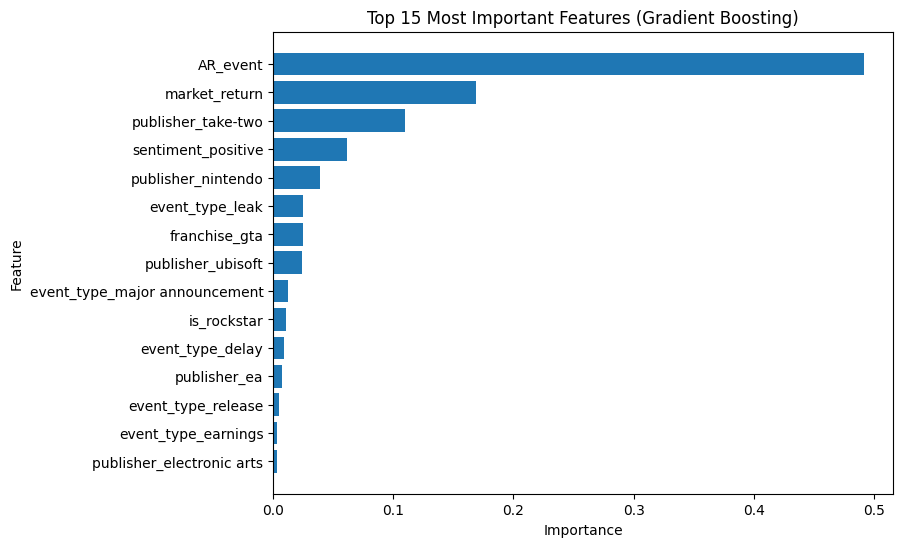

In [43]:
top = imp_df.head(15)

plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Most Important Features (Gradient Boosting)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [44]:
print("Class distribution:")
print(df['impact_label_num'].value_counts().sort_index())
print("\nPercentages:")
print(df['impact_label_num'].value_counts(normalize=True).sort_index())

Class distribution:
impact_label_num
0    28
1    17
2    27
Name: count, dtype: int64

Percentages:
impact_label_num
0    0.388889
1    0.236111
2    0.375000
Name: proportion, dtype: float64
